In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import xarray as xr
import glob
import matplotlib.pyplot as plt

import glob

import sys

import xarray as xr
import pandas as pd
import random

In [3]:
#device = torch.device("cuda:0")
device = 'cpu'


In [4]:
inp_files_raw = glob.glob("/glade/work/qingyuany/Climsim/train/*/E3SM*mli*.nc")
out_files_raw = glob.glob("/glade/work/qingyuany/Climsim/train/*/E3SM*mlo*.nc")
random.shuffle(inp_files_raw)
inp_files_raw = inp_files_raw[:5]

inp_files = []
count = 0
for f in inp_files_raw:
    temp = f.replace("mli", "mlo")
    if temp in out_files_raw:
        inp_files.append(f)

    else:
        count += 1
        


In [5]:
inp_var_3d_nm = ['state_t', 'state_q0001', 'state_q0002', 'state_q0003']
inp_var_2d_nm = ['state_ps', 'pbuf_SOLIN', 'pbuf_LHFLX', 'pbuf_SHFLX']
inp_var_1d_nm = ['ymd', 'tod']
                 

out_var_3d_nm = ['state_t', 'state_q0001', 'state_q0002', 'state_q0003']
out_var_2d_nm = ['cam_out_NETSW',  
                 'cam_out_FLWDS', 'cam_out_PRECSC', 'cam_out_PRECC', 'cam_out_SOLS', 
                 'cam_out_SOLL', 'cam_out_SOLSD', 'cam_out_SOLLD']



In [27]:
%run ../dataset/dataset.py


In [28]:
dataset = Climsim_Dataset_xy(
    input_paths = inp_files,
    xname3d = inp_var_3d_nm,
    xname2d = inp_var_2d_nm,
    xname1d = inp_var_1d_nm,
    yname3d = out_var_3d_nm,
    yname2d = out_var_2d_nm       
)

In [29]:
dataloader = DataLoader(dataset, batch_size=32, pin_memory=True)

In [30]:
for x3d, x2d, y3d, y2d in dataloader:
    break

(array([1.000e+00, 3.000e+00, 3.000e+00, 5.000e+00, 8.000e+00, 3.000e+01,
        1.610e+02, 1.693e+03, 1.100e+01, 5.000e+00]),
 array([-8.59902427e-12, -7.38492861e-12, -6.17083338e-12, -4.95673771e-12,
        -3.74264205e-12, -2.52854660e-12, -1.31445104e-12, -1.00355528e-13,
         1.11373996e-12,  2.32783562e-12,  3.54193107e-12]),
 <BarContainer object of 10 artists>)

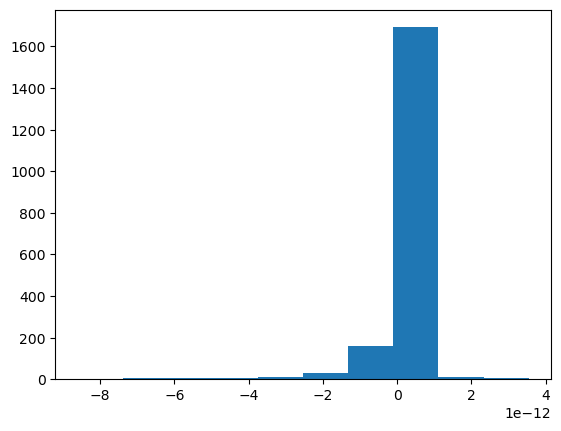

In [66]:
inp_mean = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/input_mean.nc")

inp_mean

<xarray.Dataset> Size: 5kB
Dimensions:           (lev: 60)
Dimensions without coordinates: lev
Data variables: (12/27)
    cam_in_ALDIF      float64 8B ...
    cam_in_ALDIR      float64 8B ...
    cam_in_ASDIF      float64 8B ...
    cam_in_ASDIR      float64 8B ...
    cam_in_ICEFRAC    float64 8B ...
    cam_in_LANDFRAC   float64 8B ...
    ...                ...
    state_q0001       (lev) float64 480B ...
    state_q0002       (lev) float64 480B ...
    state_q0003       (lev) float64 480B ...
    state_t           (lev) float64 480B ...
    state_u           (lev) float64 480B ...
    state_v           (lev) float64 480B ...

In [24]:

var_mean = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/input_mean.nc")



In [28]:
torch.from_numpy(var_mean['state_ps'].values).float()




tensor(98623.6641)

In [25]:
temp_out= norm_cumulative(dataloader, x3d_channel = slice(0,1), x3d_q_channel = slice(1,4), q_threshold = 10**(-7), device=device)



In [38]:
temp_out['x3d_std']








tensor([[ 5.9148,  8.6356,  8.4449,  6.9059,  6.7193,  9.5790, 12.1245, 12.3212,
         11.1997, 10.5867,  9.6035,  8.6539,  7.7581,  7.1986,  7.1701,  7.9377,
         10.1229, 12.2629, 10.8520,  8.7683,  5.6565,  3.5311,  3.0292,  4.1231,
          5.7152,  7.2065,  8.5365,  9.6552, 10.5978, 11.3755, 12.0166, 12.5147,
         12.8850, 13.1387, 13.2952, 13.3681, 13.3805, 13.3616, 13.3235, 13.2786,
         13.2317, 13.1716, 13.1104, 13.0540, 13.0087, 12.9880, 12.9937, 13.0231,
         13.0731, 13.1378, 13.2045, 13.2718, 13.3487, 13.4374, 13.5494, 13.6948,
         13.8809, 14.1109, 14.3503, 14.6589]])

In [66]:
output = cal_input_mean_std(x3d[:,0:1,:], x2d, x3d_q = x3d[:,1:,:])

In [71]:
output[4].shape

torch.Size([3, 60])

In [11]:

grid_info = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/grid_info/ClimSim_low-res_grid-info.nc")

In [ ]:

qc_exp_lambda =pd.read_table('/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/qc_exp_lambda_large.txt',sep = ',')
qi_exp_lambda =pd.read_table('/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/qi_exp_lambda_large.txt',sep = ',')
qn_exp_lambda =pd.read_table('/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/qn_exp_lambda_large.txt',sep = ',')




In [30]:
input_max = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/input_max.nc")
input_min = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/input_min.nc")

input_mean = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/input_mean.nc")
input_std = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/input_std.nc")



In [49]:
output_scale = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/outputs/output_scale.nc")

In [39]:
input_std.state_t.values

array([ 6.71706173,  8.63296262,  8.21371332,  6.77500255,  6.27149497,
        8.27217209, 10.16071739, 10.10292062,  9.19845881,  8.78710189,
        8.11289917,  7.41082946,  6.7127552 ,  6.32224402,  6.52887706,
        7.64166185, 10.01512821, 11.82419661, 10.05851204,  8.26639149,
        5.48398684,  4.06343727,  4.29860299,  5.45801559,  6.94285431,
        8.29411015,  9.508116  , 10.50739595, 11.33706323, 11.995402  ,
       12.51172186, 12.89314463, 13.16308583, 13.33206223, 13.41158658,
       13.41614134, 13.36929007, 13.2919936 , 13.20225242, 13.11237189,
       13.02778932, 12.95314415, 12.89045018, 12.84020914, 12.80383907,
       12.78463976, 12.78349997, 12.80104861, 12.83704022, 12.88828674,
       12.95170799, 13.02530669, 13.10992877, 13.21009871, 13.33914497,
       13.51771329, 13.78030565, 14.08464245, 14.40614037, 14.77349733])

In [55]:
xnames = ['state_t', 'state_q0001', 'state_q0002', 'state_q0003', 'state_u', 'state_v']
ynames = ['state_t', 'state_q0001', 'state_q0002', 'state_q0003']



In [966]:
sum(p.numel() for p in model.parameters())

147592

In [967]:

#xname2d, yname2d, inp_paths, ncols = 384, n_lev = 60, transform = None
trn_dataset = Climsim_Dataset_x(xnames, ynames, inp_file_trn)
val_dataset = Climsim_Dataset_x(xnames, ynames, inp_file_val)


In [968]:
trn_loader = DataLoader(trn_dataset, batch_size = 50, shuffle=True, 
                        num_workers=14,
                        prefetch_factor=2,
                        persistent_workers=True,
                        pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size = 2,shuffle=True, num_workers= 16)


In [969]:
#sample_mean, sample_mu = compute_mean_std(trn_loader, device=device)

In [970]:
x_mean = torch.tensor([ 2.4719e+02,  2.5703e-03,  7.3166e-06,  3.5879e-06,  9.1282e+00, -2.4832e-02]).view(6, 1)
x_std =  torch.tensor([ 3.0357e+01, 4.2134e-03, 2.1530e-05, 1.3419e-05, 1.8984e+01, 7.1473e+00]).view(6,1)


# x_mean = torch.tensor([ 2.4719e+02,  2.5703e-03]).view(2, 1)
# x_std =  torch.tensor([ 3.0357e+01, 4.2134e-03]).view(2,1)

normalizing_mu_std = [x_mean, x_std]

In [971]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-3,
    weight_decay=1e-4
)

In [972]:
epoch_training(model, trn_loader, val_loader, optimizer, 100000, normalizing_mu_std, device = device, n_epochs = 200)

epoch 000 | train loss   0.3492 recon   0.3458 kl  83.3074 || val loss   0.1965 recon   0.1902 kl  78.7981
epoch 001 | train loss   0.0884 recon   0.0797 kl  73.4281 || val loss   0.0461 recon   0.0358 kl  64.7024
epoch 002 | train loss   0.0347 recon   0.0244 kl  51.9636 || val loss   0.0364 recon   0.0265 kl  40.9320
epoch 003 | train loss   0.0267 recon   0.0181 kl  31.1781 || val loss   0.0287 recon   0.0206 kl  25.1848
epoch 004 | train loss   0.0206 recon   0.0142 kl  18.0732 || val loss   0.0227 recon   0.0164 kl  15.8000
epoch 005 | train loss   0.0162 recon   0.0111 kl  11.5507 || val loss   0.0222 recon   0.0176 kl   9.6477
epoch 006 | train loss   0.0142 recon   0.0097 kl   8.6302 || val loss   0.0133 recon   0.0089 kl   7.9411
epoch 007 | train loss   0.0123 recon   0.0082 kl   6.9782 || val loss   0.0128 recon   0.0084 kl   6.7618
epoch 008 | train loss   0.0113 recon   0.0073 kl   5.9723 || val loss   0.0104 recon   0.0061 kl   5.9323
epoch 009 | train loss   0.0103 recon

KeyboardInterrupt: 

In [973]:
val_data = next(iter(val_loader))
val_data = val_data.reshape(-1, 6, 60)

val_data_norm = (val_data -x_mean)/x_std

In [974]:
model.eval()
with torch.no_grad():
    yy, _, _, = model(val_data_norm.to(device))

In [975]:

yy = yy.cpu().detach().numpy()
yy = yy * x_std.numpy() + x_mean.numpy()

val_data = val_data.cpu().detach().numpy()

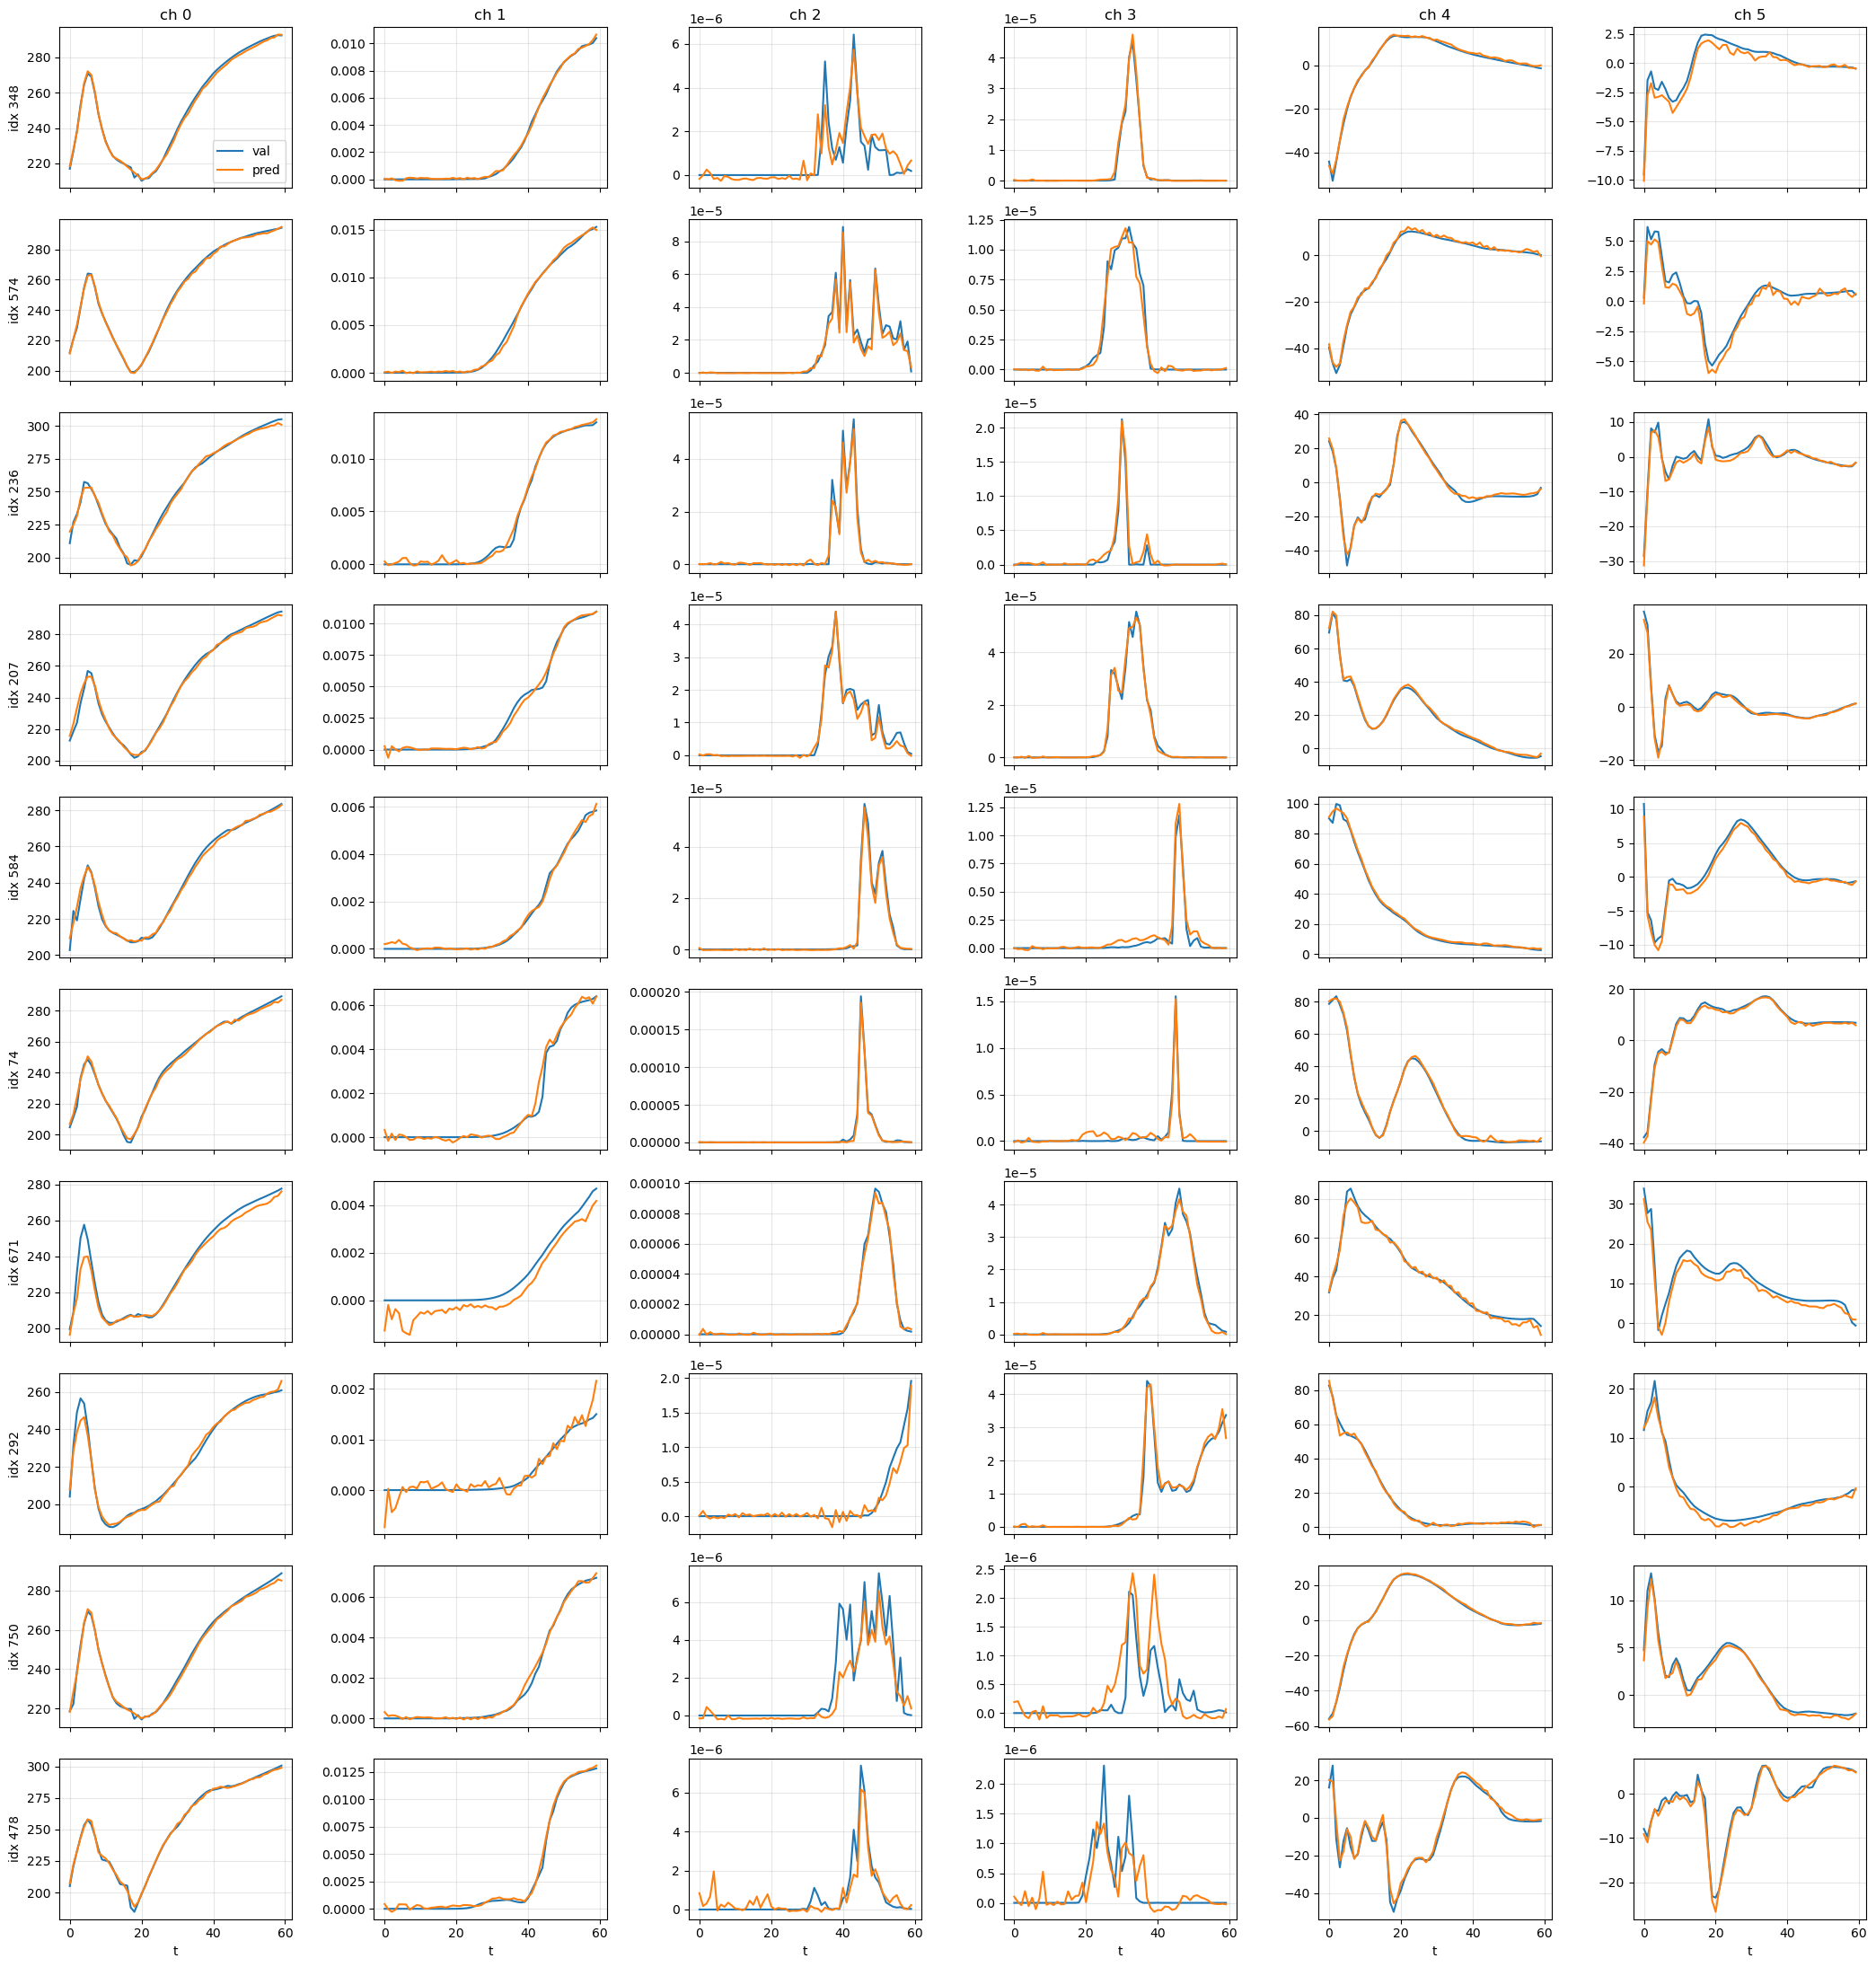

In [977]:
random_plot(val_data, yy, 10)